# TRT-LLM Benchmark Results — Llama 3.1 70B

Compares roofline estimator predictions against TRT-LLM gptManagerBenchmark (static batching) measurements.

Set `WORKLOAD` and `INSTANCE` below.

In [1]:
import json
import glob
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ─── Configuration ─────────────────────────────────────────────────
WORKLOAD = "in763-out232"
INSTANCE = "g6-48xlarge"   # subdirectory name in measured/
BENCH_TOOL = "gptBench"    # gptBench or trtllm-bench
# ───────────────────────────────────────────────────────────────────

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
PRED_DIR = os.path.join(BASE_DIR, WORKLOAD, "predicted")
MEAS_DIR = os.path.join(BASE_DIR, WORKLOAD, "measured", INSTANCE, BENCH_TOOL, "log")

INSTANCE_MAP = {
    "g5-48xlarge": "g5.48xlarge",
    "g6-48xlarge": "g6.48xlarge",
    "g6e-48xlarge": "g6e.48xlarge",
    "p4d-24xlarge": "p4d.24xlarge",
    "p5-48xlarge": "p5.48xlarge",
}

COLS = ["ttft_ms", "tpot_ms", "e2e_ms", "rps"]
JOIN_KEYS = ["tp", "pp", "batch"]

print(f"Workload: {WORKLOAD}")
print(f"Instance: {INSTANCE}")
print(f"Predicted dir: {PRED_DIR} ({len(glob.glob(os.path.join(PRED_DIR, 'est_*.json')))} files)")
print(f"Measured dir: {MEAS_DIR} ({len(glob.glob(os.path.join(MEAS_DIR, '*.log')))} logs)")

Workload: in763-out232
Instance: g6-48xlarge
Predicted dir: /home/ubuntu/ShuntServe/ArtifactEvaluation/PerformanceEstimation/trtllm/llama3-70b/in763-out232/predicted (20 files)
Measured dir: /home/ubuntu/ShuntServe/ArtifactEvaluation/PerformanceEstimation/trtllm/llama3-70b/in763-out232/measured/g6-48xlarge/gptBench/log (6 logs)


## Helper Functions

In [2]:
def parse_gptbench_log(filepath: str) -> dict:
    """Parse gptManagerBenchmark log file into a dict of metrics."""
    metrics = {}
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line.startswith("[BENCHMARK]"):
                continue
            parts = line.replace("[BENCHMARK] ", "").strip()
            tokens = parts.rsplit(" ", 1)
            if len(tokens) != 2:
                continue
            key_raw, val_str = tokens
            key = re.sub(r'\(.*?\)', '', key_raw).strip()
            try:
                metrics[key] = float(val_str)
            except ValueError:
                metrics[key] = val_str
    return metrics


def parse_log_filename(filename: str) -> dict:
    """Extract tp, pp, bs from filename like trtllm_tp8_pp1_bs16.log"""
    m = re.match(r'trtllm_tp(\d+)_pp(\d+)_bs(\d+)\.log', filename)
    if m:
        return {"tp": int(m.group(1)), "pp": int(m.group(2)), "batch": int(m.group(3))}
    return None


def load_measured(meas_dir: str) -> pd.DataFrame:
    """Load all gptManagerBenchmark log files into a DataFrame."""
    rows = []
    for filepath in sorted(glob.glob(os.path.join(meas_dir, "trtllm_*.log"))):
        filename = os.path.basename(filepath)
        info = parse_log_filename(filename)
        if info is None:
            continue
        metrics = parse_gptbench_log(filepath)
        if not metrics or metrics.get("num_samples", 0) == 0:
            continue
        
        ttft = metrics.get("avg_time_to_first_token", 0)
        e2e = metrics.get("avg_sequence_latency", 0)
        itl = metrics.get("avg_inter_token_latency", 0)
        
        rows.append({
            "tp": info["tp"],
            "pp": info["pp"],
            "batch": info["batch"],
            "ttft_ms": round(ttft, 2),
            "tpot_ms": round(itl, 4),
            "e2e_ms": round(e2e, 2),
            "rps": round(metrics.get("seq_throughput", 0), 4),
            "token_throughput": round(metrics.get("token_throughput", 0), 2),
            "num_samples": int(metrics.get("num_samples", 0)),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(JOIN_KEYS).reset_index(drop=True)
    return df


def load_predicted(pred_dir: str, instance_filter: str = None) -> pd.DataFrame:
    """Load estimator prediction JSONs."""
    files = sorted(glob.glob(os.path.join(pred_dir, "est_*.json")))
    rows = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        if not d.get("feasible", False):
            continue
        inst = d["instance_type"]
        if instance_filter:
            norm_inst = inst.replace(".", "-")
            norm_filter = instance_filter.replace(".", "-")
            if norm_inst != norm_filter:
                continue
        for entry in d.get("batch_sweep", []):
            rows.append({
                "tp": d["tp_size"],
                "pp": d["pp_size"],
                "batch": entry["batch_size"],
                "ttft_ms": round(entry.get("ttft_ms", 0), 2),
                "tpot_ms": round(entry.get("tpot_ms", 0), 4),
                "e2e_ms": round(entry["batch_latency_ms"], 2),
                "rps": round(entry["throughput_rps"], 4),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(JOIN_KEYS).reset_index(drop=True)
    return df


def merge_est_meas(est_df, meas_df) -> pd.DataFrame:
    merged = pd.merge(est_df, meas_df, on=JOIN_KEYS, suffixes=("_est", "_meas"))
    return merged.sort_values(JOIN_KEYS).reset_index(drop=True)


def compute_mape(merged_df) -> pd.DataFrame:
    def _mape(g):
        return pd.Series({
            f"{c}_mape%": ((g[f"{c}_est"] - g[f"{c}_meas"]).abs() / g[f"{c}_meas"].abs().clip(lower=1e-9) * 100).mean()
            for c in COLS
        })
    return merged_df.groupby(["tp", "pp"]).apply(_mape).round(2).reset_index()


def compute_overall_mape(merged_df) -> pd.Series:
    result = pd.Series({
        f"{c}_mape%": ((merged_df[f"{c}_est"] - merged_df[f"{c}_meas"]).abs() / merged_df[f"{c}_meas"].abs().clip(lower=1e-9) * 100).mean()
        for c in COLS
    })
    return result.round(2)


def max_batch_summary(df):
    return (
        df.loc[df.groupby(["tp", "pp"])["batch"].idxmax()]
        .sort_values(["tp", "pp"])
        .reset_index(drop=True)
    )

---
## 1. Estimated

In [3]:
est_df = load_predicted(PRED_DIR, INSTANCE)
print(f"Estimated: {len(est_df)} rows, {est_df.groupby(['tp','pp']).ngroups} configs")
max_batch_summary(est_df)

Estimated: 18 rows, 3 configs


,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps
0,2,4,11,1926.46,22.2222,58637.61,0.1876
1,4,2,30,7961.96,4.2504,37544.48,0.7991
2,8,1,33,14235.36,2.3099,31920.33,1.0338


---
## 2. Measured

In [4]:
meas_df = load_measured(MEAS_DIR)
if meas_df.empty:
    print("No measured data yet.")
else:
    meas_with_mape = pd.merge(meas_df, est_df, on=JOIN_KEYS, suffixes=('', '_est'))
    for c in COLS:
        meas_with_mape[f"{c}_mape%"] = ((meas_with_mape[f"{c}_est"] - meas_with_mape[c]).abs() / meas_with_mape[c].abs().clip(lower=1e-9) * 100).round(2)
    drop_cols = [f"{c}_est" for c in COLS]
    meas_with_mape = meas_with_mape.drop(columns=drop_cols)
    print(f"Measured: {len(meas_df)} rows, {meas_df.groupby(['tp','pp']).ngroups} configs")
    display(max_batch_summary(meas_with_mape))

Measured: 6 rows, 1 configs


,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps,token_throughput,num_samples,ttft_ms_mape%,tpot_ms_mape%,e2e_ms_mape%,rps_mape%
0,8,1,32,26087.2,196.43,71461.45,0.45,103.73,320,47.09,98.8,56.12,126.76


---
## 3. Estimated vs Measured

In [5]:
if not meas_df.empty:
    merged = merge_est_meas(est_df, meas_df)
    print(f"Matched: {len(merged)} rows")
    display(merged)
else:
    print("No measured data to compare.")

Matched: 6 rows


,tp,pp,batch,ttft_ms_est,tpot_ms_est,e2e_ms_est,rps_est,ttft_ms_meas,tpot_ms_meas,e2e_ms_meas,rps_meas,token_throughput,num_samples
0,8,1,1,431.37,58.4730,13997.10,0.0714,1099.87,75.90,18632.28,0.05,12.45,10
1,8,1,2,862.75,29.5139,14557.20,0.1374,2255.73,77.97,20267.44,0.10,22.89,20
2,8,1,4,1725.50,15.0344,15677.40,0.2551,4647.92,81.95,23577.96,0.17,39.36,40
3,8,1,8,3451.00,7.7946,17917.81,0.4465,9527.28,92.84,30972.29,0.26,59.92,80
4,8,1,16,6901.99,4.1747,22398.61,0.7143,15264.80,128.29,44900.81,0.36,82.57,160
5,8,1,32,13803.98,2.3648,31360.23,1.0204,26087.20,196.43,71461.45,0.45,103.73,320


### 3a. MAPE per Config (%)

In [6]:
if not meas_df.empty:
    display(compute_mape(merged))

,tp,pp,ttft_ms_mape%,tpot_ms_mape%,e2e_ms_mape%,rps_mape%
0,8,1,58.51,75.65,39.16,71.19


### 3b. Overall MAPE

In [7]:
if not meas_df.empty:
    overall = compute_overall_mape(merged)
    print("Overall MAPE:")
    for k, v in overall.items():
        print(f"  {k}: {v}%")

Overall MAPE:
  ttft_ms_mape%: 58.51%
  tpot_ms_mape%: 75.65%
  e2e_ms_mape%: 39.16%
  rps_mape%: 71.19%


### 3c. Config Summary (all batch sizes, with MAPE)

In [8]:
if not meas_df.empty:
    summary = merged[["tp", "pp", "batch"]].copy()
    for c in COLS:
        summary[f"{c}_est"] = merged[f"{c}_est"].values
        summary[f"{c}_meas"] = merged[f"{c}_meas"].values
        meas_vals = merged[f"{c}_meas"].values
        summary[f"{c}_mape%"] = (abs(merged[f"{c}_est"].values - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100).round(2)
    display(summary)

,tp,pp,batch,ttft_ms_est,ttft_ms_meas,ttft_ms_mape%,tpot_ms_est,tpot_ms_meas,tpot_ms_mape%,e2e_ms_est,e2e_ms_meas,e2e_ms_mape%,rps_est,rps_meas,rps_mape%
0,8,1,1,431.37,1099.87,60.78,58.4730,75.90,22.96,13997.10,18632.28,24.88,0.0714,0.05,42.80
1,8,1,2,862.75,2255.73,61.75,29.5139,77.97,62.15,14557.20,20267.44,28.17,0.1374,0.10,37.40
2,8,1,4,1725.50,4647.92,62.88,15.0344,81.95,81.65,15677.40,23577.96,33.51,0.2551,0.17,50.06
3,8,1,8,3451.00,9527.28,63.78,7.7946,92.84,91.60,17917.81,30972.29,42.15,0.4465,0.26,71.73
4,8,1,16,6901.99,15264.80,54.78,4.1747,128.29,96.75,22398.61,44900.81,50.12,0.7143,0.36,98.42
5,8,1,32,13803.98,26087.20,47.09,2.3648,196.43,98.80,31360.23,71461.45,56.12,1.0204,0.45,126.76


---
## 4. Estimated vs Measured Bar Charts

Per strategy (tp, pp), across all batch sizes.  
Left: raw values. Right: normalized to batch=1.

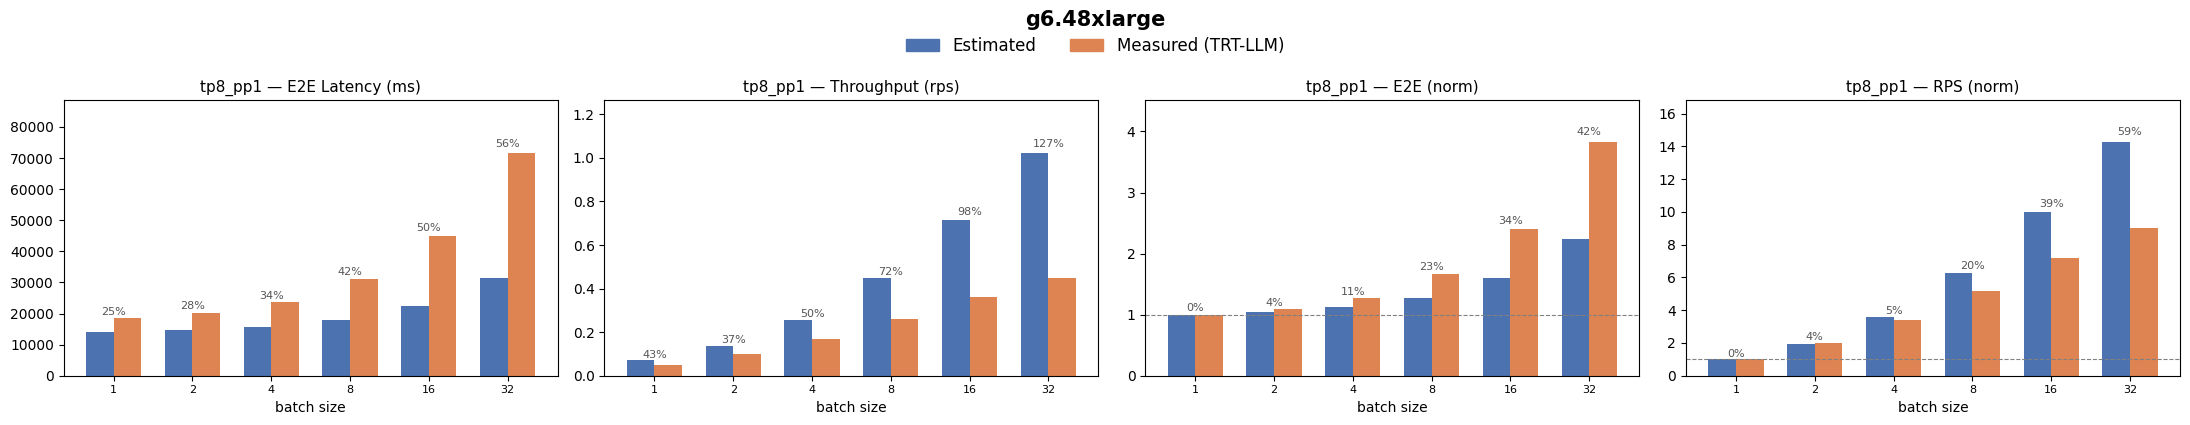

In [9]:
PLOT_COLS = ["e2e_ms", "rps"]
PLOT_LABELS = {"e2e_ms": "E2E Latency (ms)", "rps": "Throughput (rps)"}
NORM_LABELS = {"e2e_ms": "E2E (norm)", "rps": "RPS (norm)"}
C_EST, C_MEAS = "#4C72B0", "#DD8452"

if not meas_df.empty:
    strat_groups = list(merged.groupby(["tp", "pp"]))
    n_strats = len(strat_groups)

    fig, axes = plt.subplots(n_strats, 4, figsize=(22, 4 * n_strats))
    if n_strats == 1:
        axes = [axes]

    fig.legend(
        handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (TRT-LLM)")],
        loc="upper center", ncol=2, fontsize=12, frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )
    fig.suptitle(f"{INSTANCE_MAP.get(INSTANCE, INSTANCE)}", fontsize=15, fontweight="bold", y=1.05)

    for row, ((tp, pp), grp) in enumerate(strat_groups):
        grp = grp.sort_values("batch")
        batches = grp["batch"].values
        x = np.arange(len(batches))
        w = 0.35

        for ci, c in enumerate(PLOT_COLS):
            est_vals = grp[f"{c}_est"].values.astype(float)
            meas_vals = grp[f"{c}_meas"].values.astype(float)
            mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

            # Raw
            ax_raw = axes[row][ci]
            be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
            bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
            for i, mp in enumerate(mape_vals):
                top = max(be[i].get_height(), bm[i].get_height())
                ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
            ax_raw.set_title(f"tp{tp}_pp{pp} — {PLOT_LABELS[c]}", fontsize=11)
            ax_raw.set_xticks(x)
            ax_raw.set_xticklabels([str(b) for b in batches], fontsize=8)
            ax_raw.set_xlabel("batch size")
            ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

            # Normalized to batch=1
            ax_norm = axes[row][ci + 2]
            base_est = est_vals[0] if est_vals[0] != 0 else 1
            base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
            norm_est = est_vals / base_est
            norm_meas = meas_vals / base_meas
            norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
            be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
            bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
            for i, d in enumerate(norm_mape):
                top = max(be2[i].get_height(), bm2[i].get_height())
                ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
            ax_norm.set_title(f"tp{tp}_pp{pp} — {NORM_LABELS[c]}", fontsize=11)
            ax_norm.set_xticks(x)
            ax_norm.set_xticklabels([str(b) for b in batches], fontsize=8)
            ax_norm.set_xlabel("batch size")
            ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
            ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

    plt.tight_layout()
    plt.show()

---
## 6. Cross-GPU Comparison (Fixed TP/PP/Batch)

Compare estimated vs measured across GPU instance types at the same parallelism strategy and batch size.
X-axis = instance type, bars = estimated vs measured.

In [ ]:
def load_all_instances(workload_dir: str, bench_tool: str = "gptBench") -> pd.DataFrame:
    """Load measured logs from ALL instance subdirectories."""
    meas_root = os.path.join(workload_dir, "measured")
    if not os.path.isdir(meas_root):
        return pd.DataFrame()
    rows = []
    for inst_dir in sorted(os.listdir(meas_root)):
        log_dir = os.path.join(meas_root, inst_dir, bench_tool, "log")
        if not os.path.isdir(log_dir):
            continue
        df = load_measured(log_dir)
        if not df.empty:
            df["instance"] = inst_dir
            rows.append(df)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def load_all_predicted(pred_dir: str) -> pd.DataFrame:
    """Load estimator predictions for ALL instances."""
    files = sorted(glob.glob(os.path.join(pred_dir, "est_*.json")))
    rows = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        if not d.get("feasible", False):
            continue
        inst = d["instance_type"].replace(".", "-")
        for entry in d.get("batch_sweep", []):
            rows.append({
                "instance": inst,
                "tp": d["tp_size"],
                "pp": d["pp_size"],
                "batch": entry["batch_size"],
                "ttft_ms": round(entry.get("ttft_ms", 0), 2),
                "tpot_ms": round(entry.get("tpot_ms", 0), 4),
                "e2e_ms": round(entry["batch_latency_ms"], 2),
                "rps": round(entry["throughput_rps"], 4),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["instance", "tp", "pp", "batch"]).reset_index(drop=True)
    return df


WORKLOAD_DIR = os.path.join(BASE_DIR, WORKLOAD)
all_meas = load_all_instances(WORKLOAD_DIR, BENCH_TOOL)
all_pred = load_all_predicted(PRED_DIR)

avail_instances = sorted(all_meas["instance"].unique()) if not all_meas.empty else []
print(f"Measured instances: {avail_instances}")
print(f"Predicted instances: {sorted(all_pred["instance"].unique()) if not all_pred.empty else []}")

if not all_meas.empty:
    # Show available (tp, pp, batch) combos across instances
    common = all_meas.groupby(["tp", "pp", "batch"])["instance"].nunique().reset_index()
    common.columns = ["tp", "pp", "batch", "n_instances"]
    print()
    print("Configs with measurements from multiple instances:")
    display(common[common["n_instances"] > 1].head(20) if len(common[common["n_instances"] > 1]) > 0 else "Only 1 instance available so far")

In [ ]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 8
CROSS_PP = 1
CROSS_BATCH_SIZES = [1, 8, 32]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not all_meas.empty and len(avail_instances) >= 2:
    # Merge all predictions + measurements
    cross_merged = pd.merge(
        all_pred, all_meas,
        on=["instance", "tp", "pp", "batch"],
        suffixes=("_est", "_meas"),
    )
    # Filter to requested tp/pp
    cross_merged = cross_merged[(cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    if cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (TRT-LLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=8, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=8, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()
elif not all_meas.empty:
    print(f"Only 1 instance ({avail_instances[0]}) measured so far. Need >= 2 for cross-GPU comparison.")
else:
    print("No measured data available.")

---
## 5. Filter

In [10]:
def filter_df(df, tp=None, pp=None):
    if tp:
        df = df[df["tp"] == tp]
    if pp:
        df = df[df["pp"] == pp]
    return df.reset_index(drop=True)

# Example: filter_df(summary, tp=8, pp=1)